In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
import os

In [21]:
DECISION_FILTER = "approved" # "approved" or "all_decisions"
DATASET_FILTER = "_pars" # "" or "_pars"

In [ ]:
DATASET_DIR = f"./../data/datasets/1995{DATASET_FILTER}/{DECISION_FILTER}"

EMA = f"{DATASET_DIR}/EMA.csv"
PMDA = f"{DATASET_DIR}/PMDA.csv"
SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
TGA = f"{DATASET_DIR}/TGA.csv"
# FDA = f"{DATASET_DIR}/FDA.csv"
# HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = f"./../analysis/{DECISION_FILTER}/overlap"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
ema = pd.read_csv(EMA)
pmda = pd.read_csv(PMDA)
swissmedic = pd.read_csv(SWISSMEDIC)
tga = pd.read_csv(TGA)
# fda = pd.read_csv(FDA)
# healthcanada = pd.read_csv(HEALTHCANADA)
overall = pd.read_csv(OVERALL)

In [5]:
overall.head()

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,eli lilly regional operations gmbh,eli lilly,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,celgene europe bv,celgene,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA
2,intramuscular,30.11.2012,2012.0,authorised,ema,approved,19.09.2013,2013,mental and behavioural disorders,abilify-maintena-epar-public-assessment-report...,...,otsuka pharmaceutical europe ltd,otsuka,ema/737723/2013,aripiprazole,no,no,powder; solvent,emea/h/c/002755/0000,na,EMA
3,oral,12.09.2019,2019.0,authorised,ema,approved,25.02.2021,2021,neoplasms,abiraterone-accord-epar-public-assessment-repo...,...,accord healthcare s.l.u.,accord,ema/174959/2021,abiraterone acetate,yes,no,tablet,emea/h/c/005408/0000,NaN,EMA
4,oral,29.06.2020,2020.0,authorised,ema,approved,22.04.2021,2021,neoplasms,abiraterone-krka-epar-public-assessment-report...,...,"krka, d.d., novo mesto",krka,ema/653711/2021,abiraterone acetate,yes,no,tablet,emea/h/c/005649/0000,NaN,EMA


In [6]:
def plot_agency_distribution(dataset, data_col, figsize=(4.2, 4.2), bar_color='darkseagreen', 
                            edge_color='navy', xlabel_fontsize=12, ylabel_fontsize=12):
    plt.figure(figsize=figsize)
    
    agency_counts = dataset.groupby(data_col)['Agency'].nunique()
    agency_counts.value_counts().sort_index().plot(kind='bar', color=bar_color, edgecolor=edge_color)
    
    plt.xlabel(f'$N$ drug agencies', fontsize=xlabel_fontsize)
    plt.ylabel(f'$N$ {data_col.lower().replace("_", " ")}', fontsize=ylabel_fontsize)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(agency_counts.value_counts().sort_index()):
        plt.text(i, v + max(agency_counts.value_counts()) * 0.001, str(v), 
                 ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_agency_distribution.png", dpi=300)
    plt.show()

def create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens'):
    agencies = dataset['Agency'].unique()
    heatmap = pd.DataFrame(0, index=agencies, columns=agencies)

# Get the total number of drugs per agency
    agency_drug_counts = dataset.groupby('Agency')[data_col].nunique()
    for drug in dataset[data_col].unique():
        involved_agencies = dataset[dataset[data_col] == drug]['Agency'].unique()
        for agency1, agency2 in combinations(involved_agencies, 2):
            heatmap.loc[agency1, agency2] += 1
            heatmap.loc[agency2, agency1] += 1

# Normalize by column (x-axis) agency's total drug count
    heatmap_normalized = heatmap.copy()
    for j, agency_col in enumerate(agencies):  # j is column (x-axis)
        for i, agency_row in enumerate(agencies):  # i is row (y-axis)
            if i != j:
            # Divide by the column agency's total drugs
                heatmap_normalized.loc[agency_row, agency_col] = (
                heatmap.loc[agency_row, agency_col] / agency_drug_counts[agency_col]
            )

    plt.figure(figsize=figsize)
    plt.imshow(heatmap_normalized, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Proportion of Column Agency Drugs')
    plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
    plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text with absolute and percentage values
    for i in range(len(agencies)):
        for j in range(len(agencies)):
            if i != j:  # Skip diagonal
                abs_value = int(heatmap.iloc[i, j])
                prop_value = heatmap_normalized.iloc[i, j]
            # text_color = 'white' if prop_value > 0.5 else 'black'
                text_color = "black"
                # round percent to integer if >=10%, else 1 decimal place
                if prop_value >= 0.1:
                    prop_text = f'{prop_value:.0%}'
                else:
                    prop_text = f'{prop_value:.1%}'
                plt.text(j, i, f'{abs_value}\n({prop_text})', 
                    ha='center', va='center', 
                    color=text_color, fontsize=9)

    # plt.title('Shared Drugs (% of horizontal axis agency)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_normalized_heatmap.png", dpi=300)
    plt.show()

def analyze_drug_duplicates(dataset, data_col, top_n_drugs=2):

    # Create a subset df with drug names which appear multiple times within the SAME agency
    duplicates_within_agency = dataset[dataset.duplicated(subset=[data_col, 'Agency'], keep=False)]
    
    # Find drug names which are cross-agency duplicates (appear in multiple different agencies)
    cross_agency_duplicates = dataset[dataset.duplicated(subset=[data_col], keep=False)]
    
    # Drop in-agency duplicates from this subset to keep only cross-agency duplicates
    cross_agency_duplicates = cross_agency_duplicates[~cross_agency_duplicates.index.isin(duplicates_within_agency.index)]
    
    # Find the top shared drugs across multiple agencies and create df subset with them
    drug_agency_count = dataset.groupby(data_col)['Agency'].nunique()
    top_shared_drugs = drug_agency_count[drug_agency_count > top_n_drugs].index.tolist()
    top_shared_drugs_df = dataset[dataset[data_col].isin(top_shared_drugs)]
    
    print(20 * "-")
    print(f"{len(dataset):<10} Length of the combined (overall) dataset including all datapoints")
    print(f"{len(duplicates_within_agency):<10} Length of the subset including in-agency duplicates ({data_col} present multiple times within the same agency)")
    print(f"{len(cross_agency_duplicates):<10} Length of the subset including cross-agency duplicates ({data_col} present in multiple different agencies)")
    print(20 * "-")
    print(f"{dataset[data_col].nunique():<10} N of unique {data_col} in the combined dataset")
    print(f"{duplicates_within_agency[data_col].nunique():<10} N of unique {data_col} in the in-agency duplicates subset")
    print(f"{cross_agency_duplicates[data_col].nunique():<10} N of unique {data_col} in the cross-agency duplicates subset")
    
    return {
        'duplicates_within_agency': duplicates_within_agency,
        'cross_agency_duplicates': cross_agency_duplicates,
        'top_shared_drugs_df': top_shared_drugs_df,
        'top_shared_drugs': top_shared_drugs
    }

In [7]:
def analyze_agency_drug_sharing(dataset, data_col='Drug_name', output_file=None):

    agencies = sorted(dataset['Agency'].unique())
    
    # Filter out rows with missing drug names
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Create a mapping of drug to set of agencies
    drug_to_agencies = dataset_clean.groupby(data_col)['Agency'].apply(set).to_dict()
    
    # Initialize results dictionary
    results = {agency: {} for agency in agencies}
    
    # Prepare output capture
    output_lines = []
    
    # For each agency, analyze its drugs
    for agency in agencies:
        # Get unique drugs for this agency, excluding NaN values
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        # Count how many agencies each drug appears in (beyond the current agency)
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            # Count other agencies (excluding current agency)
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        # Calculate percentages
        for n_shared in sharing_counts:
            percentage = (sharing_counts[n_shared] / total_drugs) * 100
            results[agency][n_shared] = percentage
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df.fillna(0).sort_index(axis=1)
    
    # Rename columns for clarity
    column_names = {}
    for col in results_df.columns:
        if col == 0:
            column_names[col] = 'Unique to agency'
        elif col == 1:
            column_names[col] = 'Shared with 1 other'
        else:
            column_names[col] = f'Shared with {col} others'
    results_df = results_df.rename(columns=column_names)
    
    # Display results
    def print_and_capture(text):
        print(text)
        output_lines.append(text)
    
    print_and_capture(f"\n{'='*80}")
    print_and_capture(f"Drug Sharing Analysis by Agency (unique deduped entries based on {data_col})")
    print_and_capture(f"{'='*80}\n")
    
    print_and_capture(f"Percentages represent proportion of each agency's unique deduped entries by {data_col}:\n")
    print_and_capture(results_df.round(2).to_string())
    
    # Also print absolute counts
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Absolute counts (by unique deduped entry in {data_col}):")
    print_and_capture(f"{'='*80}\n")
    
    # Calculate absolute counts
    counts_results = {agency: {} for agency in agencies}
    for agency in agencies:
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        for n_shared in sharing_counts:
            counts_results[agency][n_shared] = sharing_counts[n_shared]
    
    counts_df = pd.DataFrame(counts_results).T
    counts_df = counts_df.fillna(0).sort_index(axis=1).astype(int)
    counts_df = counts_df.rename(columns=column_names)
    
    print_and_capture(counts_df.to_string())
    
    # Summary statistics
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Summary Statistics by unique deduped {data_col}:")
    print_and_capture(f"{'='*80}\n")
    
    for agency in agencies:
        total = len(dataset_clean[dataset_clean['Agency'] == agency][data_col])
        total_deduped = dataset_clean[dataset_clean['Agency'] == agency][data_col].nunique()
        unique = counts_df.loc[agency, 'Unique to agency'] if 'Unique to agency' in counts_df.columns else 0
        print_and_capture(f"{agency:15} - Total: {total:4}, Total deduped: {total_deduped:4}, Unique to this agency: {unique:4} ({unique/total_deduped*100:.1f}%)")
    
    # Save to file if output_file is specified
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write('\n'.join(output_lines))
        print(f"\n Analysis saved to: {output_file}")
    
    return results_df, counts_df

In [8]:
def get_top_duplicated_drugs(dataset, data_col='Drug_name', top_n=15):

    # Filter out rows with missing values in data_col
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Count occurrences of each drug
    drug_counts = dataset_clean[data_col].value_counts()
    
    # Get top N drugs with most duplicates
    top_drugs = drug_counts.head(top_n).index.tolist()
    
    # Filter dataset for these top drugs
    top_drugs_df = dataset_clean[dataset_clean[data_col].isin(top_drugs)].copy()
    
    # Sort by data_col and then by Agency for easy comparison
    top_drugs_df = top_drugs_df.sort_values([data_col, 'Agency'])
    
    print(f"\nTop {top_n} drugs with most entries (by {data_col}):")
    print(f"{'='*80}\n")
    for i, (drug, count) in enumerate(drug_counts.head(top_n).items(), 1):
        agencies = dataset_clean[dataset_clean[data_col] == drug]['Agency'].unique()
        print(f"{i:2}. {drug:40} - {count:3} entries across {len(agencies)} agencies: {', '.join(sorted(agencies))}")
    
    # save for inspection
    top_drugs_df.to_csv(f"{SAVE_DIR}/top_{top_n}_duplicated_drugs_by_{data_col}.csv", index=False)
    
    return top_drugs_df

In [9]:
overall.head(2)

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,eli lilly regional operations gmbh,eli lilly,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,celgene europe bv,celgene,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA


# Analyse duplicates by drug_name

In [10]:
results = analyze_drug_duplicates(dataset=overall, data_col='Drug_name', top_n_drugs=10)

--------------------
3120       Length of the combined (overall) dataset including all datapoints
542        Length of the subset including in-agency duplicates (Drug_name present multiple times within the same agency)
1121       Length of the subset including cross-agency duplicates (Drug_name present in multiple different agencies)
--------------------
2030       N of unique Drug_name in the combined dataset
170        N of unique Drug_name in the in-agency duplicates subset
527        N of unique Drug_name in the cross-agency duplicates subset


In [11]:
print(results)

{'duplicates_within_agency':                Administration_route Application_date  Application_year  \
1042      intravenous; subcutaneous              NaN               NaN   
1128      intravenous; subcutaneous              NaN               NaN   
1491                    intravenous       31.03.2009            2009.0   
1494                    intravenous       26.04.2011            2011.0   
1506                           oral       08.08.2006            2006.0   
...                             ...              ...               ...   
3101                   subcutaneous       03.01.2023            2023.0   
3108  intramuscular; intraglandular       30.11.2022            2022.0   
3109                   subcutaneous              NaN               NaN   
3111                    intravenous              NaN               NaN   
3119                           oral       30.04.2015            2015.0   

                                Current_status    Dataset  Decision  \
1042       

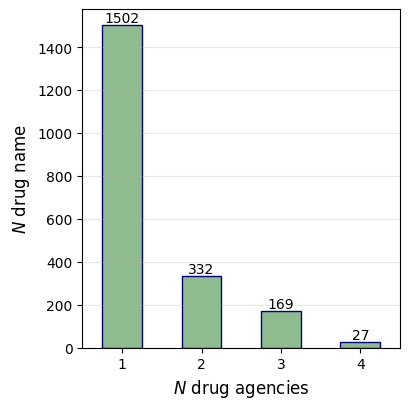

In [12]:
plot_agency_distribution(overall, 'Drug_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11006711409395974' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5239616613418531' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8402061855670103' has dtype incompatible with int64, please explicitly cast t

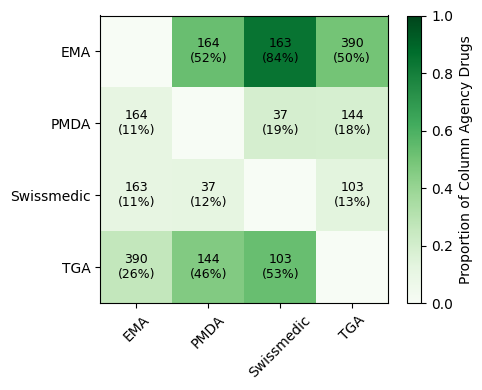

In [13]:
create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens')

In [14]:
analyze_agency_drug_sharing(dataset=overall, data_col='Drug_name', output_file=f"{SAVE_DIR}/drug_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Drug_name)

Percentages represent proportion of each agency's unique deduped entries by Drug_name:

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                    66.78                20.13                 11.28                  1.81
PMDA                   39.62                19.17                 32.59                  8.63
Swissmedic             11.34                35.05                 39.69                 13.92
TGA                    46.05                30.10                 20.41                  3.44


Absolute counts (by unique deduped entry in Drug_name):

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                      995                  300                   168                    27
PMDA                     124                   60                   102                    27
Swissmedic             

(            Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                66.778523            20.134228             11.275168   
 PMDA               39.616613            19.169329             32.587859   
 Swissmedic         11.340206            35.051546             39.690722   
 TGA                46.045918            30.102041             20.408163   
 
             Shared with 3 others  
 EMA                     1.812081  
 PMDA                    8.626198  
 Swissmedic             13.917526  
 TGA                     3.443878  ,
             Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                      995                  300                   168   
 PMDA                     124                   60                   102   
 Swissmedic                22                   68                    77   
 TGA                      361                  236                   160   
 
             Shared with 3 others  
 EMA               

In [15]:
# Get top 15 drugs with most duplicates
top_duplicated_df = get_top_duplicated_drugs(dataset=overall, data_col='Drug_name', top_n=15)
top_duplicated_df.head(3)


Top 15 drugs with most entries (by Drug_name):

 1. opdivo                                   -  20 entries across 3 agencies: EMA, PMDA, TGA
 2. comirnaty                                -  18 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 3. keytruda                                 -  15 entries across 3 agencies: EMA, PMDA, TGA
 4. actemra                                  -  13 entries across 2 agencies: PMDA, TGA
 5. rinvoq                                   -  12 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 6. spikevax                                 -  11 entries across 3 agencies: PMDA, Swissmedic, TGA
 7. enhertu                                  -   9 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 8. nuvaxovid                                -   9 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 9. avastin                                  -   8 entries across 3 agencies: EMA, PMDA, TGA
10. ultomiris                                -   8 entries acros

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
1523,intravenous,28.04.2006,2006.0,authorised,japan,approved,30.01.2008,2008,diseases of the musculoskeletal system and con...,000153709.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,no,no,concentrate,NaN,na,PMDA
1652,subcutaneous,25.08.2016,2016.0,authorised,japan,approved,10.04.2017,2017,diseases of the musculoskeletal system and con...,000224729.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,yes,no,injection,NaN,NaN,PMDA
1653,subcutaneous,30.11.2016,2016.0,authorised,japan,approved,27.07.2017,2017,diseases of the musculoskeletal system and con...,000224730.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,yes,yes,injection,NaN,NaN,PMDA


# Analyze duplicates by Non_proprietary_name

In [16]:
results = analyze_drug_duplicates(dataset=overall, data_col='Non_proprietary_name', top_n_drugs=10)

--------------------
3120       Length of the combined (overall) dataset including all datapoints
1351       Length of the subset including in-agency duplicates (Non_proprietary_name present multiple times within the same agency)
914        Length of the subset including cross-agency duplicates (Non_proprietary_name present in multiple different agencies)
--------------------
1497       N of unique Non_proprietary_name in the combined dataset
346        N of unique Non_proprietary_name in the in-agency duplicates subset
455        N of unique Non_proprietary_name in the cross-agency duplicates subset


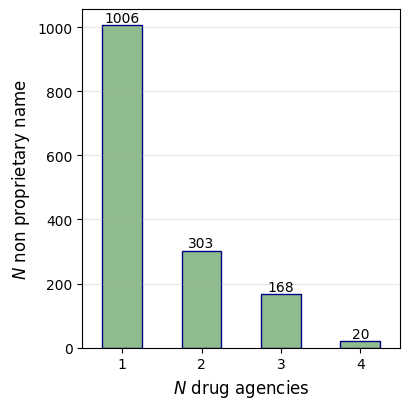

In [17]:
plot_agency_distribution(overall, 'Non_proprietary_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.16459627329192547' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5162337662337663' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_16860\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6323529411764706' has dtype incompatible with int64, please explicitly cast t

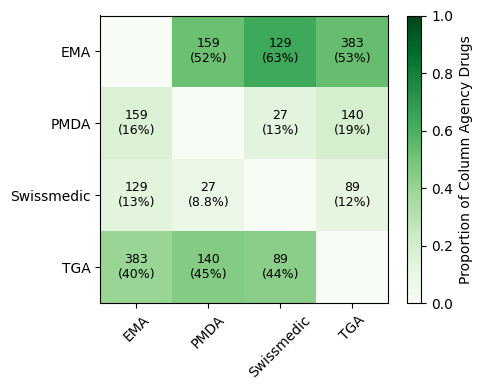

In [18]:
create_normalized_heatmap(dataset=overall, data_col='Non_proprietary_name', figsize=(5, 4), cmap='Greens')

In [19]:
analyze_agency_drug_sharing(dataset=overall, data_col='Non_proprietary_name', output_file=f"{SAVE_DIR}/non_proprietary_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Non_proprietary_name)

Percentages represent proportion of each agency's unique deduped entries by Non_proprietary_name:

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                    52.07                28.47                 17.39                  2.07
PMDA                   41.23                18.18                 34.09                  6.49
Swissmedic             33.82                22.06                 34.31                  9.80
TGA                    42.76                32.03                 22.42                  2.79


Absolute counts (by unique deduped entry in Non_proprietary_name):

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                      503                  275                   168                    20
PMDA                     127                   56                   105             

(            Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                52.070393            28.467909             17.391304   
 PMDA               41.233766            18.181818             34.090909   
 Swissmedic         33.823529            22.058824             34.313725   
 TGA                42.757660            32.033426             22.423398   
 
             Shared with 3 others  
 EMA                     2.070393  
 PMDA                    6.493506  
 Swissmedic              9.803922  
 TGA                     2.785515  ,
             Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                      503                  275                   168   
 PMDA                     127                   56                   105   
 Swissmedic                69                   45                    70   
 TGA                      307                  230                   161   
 
             Shared with 3 others  
 EMA               

In [20]:
# Get top 15 drugs with most duplicates by Non_proprietary_name
top_duplicated_nonprop_df = get_top_duplicated_drugs(dataset=overall, data_col='Non_proprietary_name', top_n=15)
top_duplicated_nonprop_df.head(3)


Top 15 drugs with most entries (by Non_proprietary_name):

 1. adalimumab                               -  27 entries across 3 agencies: EMA, PMDA, TGA
 2. clopidogrel                              -  25 entries across 1 agencies: EMA
 3. nivolumab                                -  21 entries across 3 agencies: EMA, PMDA, TGA
 4. rituximab                                -  20 entries across 3 agencies: EMA, PMDA, TGA
 5. bevacizumab                              -  19 entries across 3 agencies: EMA, PMDA, TGA
 6. tocilizumab                              -  17 entries across 3 agencies: EMA, PMDA, TGA
 7. ustekinumab                              -  17 entries across 3 agencies: EMA, PMDA, TGA
 8. aflibercept                              -  15 entries across 3 agencies: EMA, PMDA, TGA
 9. pembrolizumab                            -  15 entries across 3 agencies: EMA, PMDA, TGA
10. pegfilgrastim                            -  14 entries across 2 agencies: EMA, TGA
11. trastuzumab            

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
50,subcutaneous,03.12.2015,2015.0,authorised,ema,approved,26.01.2017,2017,diseases of the musculoskeletal system and con...,amgevita-epar-public-assessment-report_en.pdf,...,amgen europe b.v.,amgen,ema/106922/2017,adalimumab,no,no,solution,emea/h/c/004212/0000,na,EMA
54,subcutaneous,05.11.2018,2018.0,authorised,ema,approved,12.12.2019,2019,diseases of the musculoskeletal system and con...,amsparity-epar-public-assessment-report_en.pdf,...,pfizer europe ma eeig,pfizer,ema/2756/2020,adalimumab,no,no,solution,emea/h/c/004879/0000,na,EMA
251,subcutaneous,27.10.2016,2016.0,withdrawn,ema,approved,14.09.2017,2017,diseases of the musculoskeletal system and con...,cyltezo-epar-public-assessment-report_en.pdf,...,boehringer ingelheim international gmbh,boehringer ingelheim,ema/chmp/750187/2017,adalimumab,no,no,solution,emea/h/c/004319/0000,na,EMA
